In [1]:
import pandas as pd
import numpy as np

In [2]:
file_dataset_15 = r'.\rotterdam_dataset_15.xlsx'

In [3]:
cargo_data = pd.read_excel(file_dataset_15)

In [4]:
cargo_data.info()
# The result shows us that there are no missing values in the dataset.

<class 'pandas.DataFrame'>
RangeIndex: 17081 entries, 0 to 17080
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Arrival_Date   17081 non-null  datetime64[us]
 1   Vessel_ID      17081 non-null  str           
 2   Vessel_Type    17081 non-null  str           
 3   Cargo_tons     17081 non-null  int64         
 4   Berth_Time_hr  17081 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 667.4 KB


In [5]:
cargo_data.head()
# The result confirms that the entries are sorted by the Vessel_ID field.

,Arrival_Date,Vessel_ID,Vessel_Type,Cargo_tons,Berth_Time_hr
0,2022-01-01 06:18:00,V000001,Container,18090,19.9
1,2022-01-01 11:07:00,V000002,Container,10940,18.7
2,2022-01-01 04:06:00,V000003,Container,9199,20.6
3,2022-01-01 10:34:00,V000004,Container,12689,27.0
4,2022-01-01 13:10:00,V000005,Container,9413,18.5


In [6]:
print(cargo_data['Vessel_ID'].duplicated().sum())
# In order to check duplicates in the data, we check if any of the unique IDs appears more than one time.
# The result shows that there are no duplicate records in the data set.

0


In [7]:
cargo_data.describe()

,Arrival_Date,Cargo_tons,Berth_Time_hr
count,17081,17081.000000,17081.000000
mean,2023-06-29 19:00:45.018441,25254.917101,25.854446
min,2022-01-01 04:06:00,2722.000000,6.300000
25%,2022-09-19 10:42:00,13184.000000,19.600000
50%,2023-07-02 01:09:00,18964.000000,23.500000
75%,2024-04-06 19:48:00,34736.000000,33.000000
max,2024-12-31 23:27:00,135465.000000,46.300000
std,NaN,16227.924229,7.630941


In [8]:
print(cargo_data['Arrival_Date'].min())
print(cargo_data['Arrival_Date'].max())
# We can see that the arrival dates are all in the 3 year time range.

2022-01-01 04:06:00
2024-12-31 23:27:00


In [9]:
print(cargo_data['Berth_Time_hr'].min())
print(cargo_data['Berth_Time_hr'].max())
# We can see that the berth times are all in a reasonable range.

6.3
46.3


In [10]:
print(cargo_data['Cargo_tons'].min())
print(cargo_data['Cargo_tons'].max())
# We can see that the cargo weights are all in a reasonable range.

2722
135465


In [11]:
vessel_container = cargo_data[cargo_data['Vessel_Type'] == 'Container']
vessel_tanker = cargo_data[cargo_data['Vessel_Type'] == 'Tanker']
vessel_bulk = cargo_data[cargo_data['Vessel_Type'] == 'Bulk']
print(vessel_container['Vessel_Type'].count(), vessel_tanker['Vessel_Type'].count(), vessel_bulk['Vessel_Type'].count())
print(vessel_container['Vessel_Type'].count() + vessel_tanker['Vessel_Type'].count() + vessel_bulk['Vessel_Type'].count() == cargo_data['Vessel_Type'].count())
# This confirms there are no unidentified vessel types.
# The conclusion is that the data is of good quality: no missing values, no duplicates.

9496 4947 2638
True


In [12]:
group_vessel = cargo_data.groupby('Vessel_Type')
group_vessel['Cargo_tons'].describe()

,count,mean,std,min,25%,50%,75%,max
Vessel_Type,,,,,,,,
Bulk,2638.0,25075.289613,10247.520990,2722.0,17573.0,23582.0,31188.25,71381.0
Container,9496.0,14894.269166,5267.804453,3363.0,11097.0,14099.5,17727.25,62456.0
Tanker,4947.0,45238.456640,13950.573497,14279.0,35327.5,43051.0,53260.50,135465.0


In [13]:
group_vessel['Berth_Time_hr'].describe()

,count,mean,std,min,25%,50%,75%,max
Vessel_Type,,,,,,,,
Bulk,2638.0,28.076839,3.012377,19.4,26.1,28.1,30.0,39.8
Container,9496.0,19.986036,2.969624,6.3,18.0,20.0,22.0,30.7
Tanker,4947.0,35.934041,2.991642,24.3,33.8,35.9,38.0,46.3


In [14]:
import matplotlib.pyplot as plt

Cargo_tons    Axes(0.125,0.11;0.775x0.77)
dtype: object

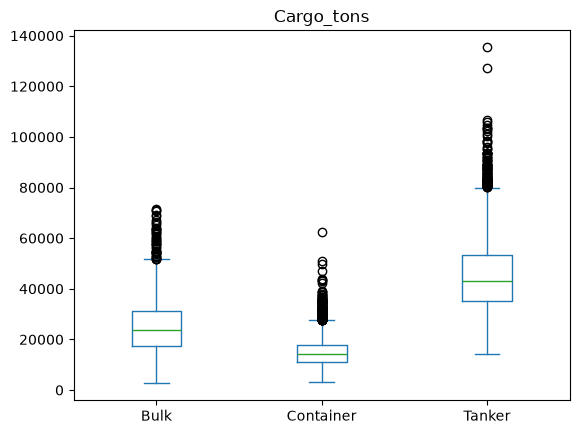

In [ ]:
cargo_data.plot(kind='box', column='Cargo_tons', by='Vessel_Type')
# This plot shows the outliers of cargo weight for each type of vessel.
# In this case, the Container and Tanker have outlier values.

In [16]:
cargo_data['YearMonth'] = cargo_data['Arrival_Date'].dt.strftime('%Y-%m')
monthly_group = cargo_data.groupby('YearMonth')
# We created a YearMonth column for more compact ploting.

<Axes: xlabel='YearMonth'>

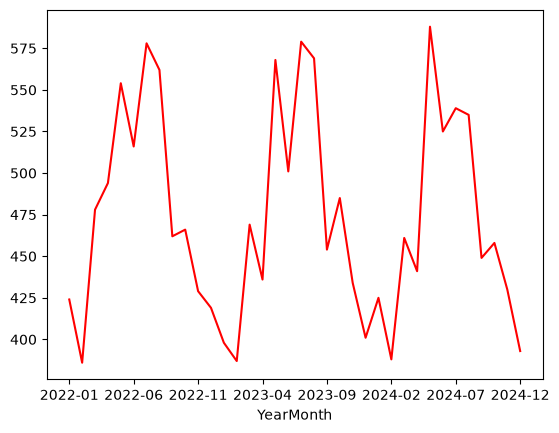

In [17]:
monthly_arrivals = monthly_group['Vessel_ID'].count()

monthly_arrivals.plot(kind='line', c='r')
# This plot shows the amount of arrivals per month.
# We notice unusually low amounts of arrivals at the beginning of each year and unusually high amounts during the summer.

<Axes: xlabel='YearMonth'>

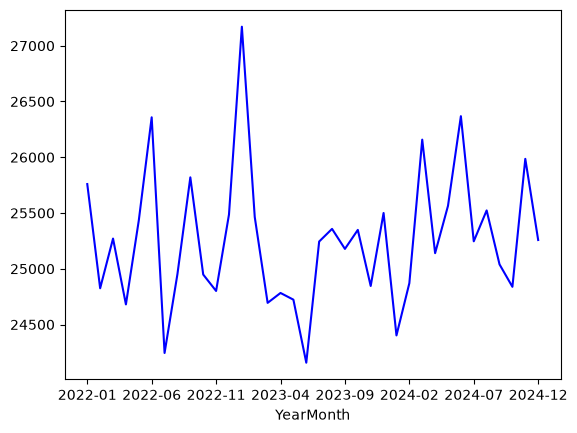

In [18]:
monthly_tons_mean = monthly_group['Cargo_tons'].mean()
monthly_tons_mean.plot(kind='line', c='b')
# The plot shows several spikes in monthly cargo weight without having a precise pattern.

<Axes: xlabel='YearMonth'>

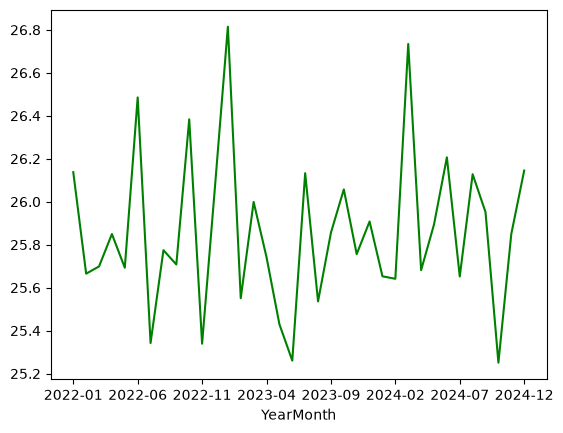

In [19]:
monthly_berth_times_mean = monthly_group['Berth_Time_hr'].mean()
monthly_berth_times_mean.plot(kind='line', c='g')
# The spikes in cargo weights are somewhat proportional to the spikes in berth times,
# showing a corelation between amount of weight and time spent at beth.

In [20]:
# The conclusion is that the data is consistent, there are no unexpected values, such as negative weights or berth times.